# TrendHub E-Commerce Analysis
**Store:** trendhub.pk  
**Analysis Date:** June 2026  
**Analyst:** Izaan


In [ ]:
import pandas as pd

df1 = pd.read_csv('orders_export_1.csv')
df2 = pd.read_csv('orders_export_2.csv')

print("File 1 shape:", df1.shape)
print("File 2 shape:", df2.shape)

print("\nFile 1 columns:")
print(df1.columns.tolist())

print("\nFile 2 columns:")
print(df2.columns.tolist())

File 1 shape: (15245, 79)
File 2 shape: (2787, 79)

File 1 columns:
['Name', 'Email', 'Financial Status', 'Paid at', 'Fulfillment Status', 'Fulfilled at', 'Accepts Marketing', 'Currency', 'Subtotal', 'Shipping', 'Taxes', 'Total', 'Discount Code', 'Discount Amount', 'Shipping Method', 'Created at', 'Lineitem quantity', 'Lineitem name', 'Lineitem price', 'Lineitem compare at price', 'Lineitem sku', 'Lineitem requires shipping', 'Lineitem taxable', 'Lineitem fulfillment status', 'Billing Name', 'Billing Street', 'Billing Address1', 'Billing Address2', 'Billing Company', 'Billing City', 'Billing Zip', 'Billing Province', 'Billing Country', 'Billing Phone', 'Shipping Name', 'Shipping Street', 'Shipping Address1', 'Shipping Address2', 'Shipping Company', 'Shipping City', 'Shipping Zip', 'Shipping Province', 'Shipping Country', 'Shipping Phone', 'Notes', 'Note Attributes', 'Cancelled at', 'Payment Method', 'Payment Reference', 'Refunded Amount', 'Vendor', 'Outstanding Balance', 'Employee', 'L

/tmp/ipykernel_6294/1062186510.py:3: DtypeWarning: Columns (33,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('orders_export_1.csv')


In [ ]:
# Combine both files
df = pd.concat([df1, df2], ignore_index=True)

print("Combined shape:", df.shape)
print("\nDate range of orders:")
df['Created at'] = pd.to_datetime(df['Created at'], utc=True)
print("Earliest order:", df['Created at'].min())
print("Latest order:", df['Created at'].max())

Combined shape: (18032, 79)

Date range of orders:
Earliest order: 2025-05-31 19:23:16+00:00
Latest order: 2026-06-09 18:09:59+00:00


In [ ]:
# Check how many cancelled orders exist
print("Financial Status breakdown:")
print(df['Financial Status'].value_counts())

print("\nFulfillment Status breakdown:")
print(df['Fulfillment Status'].value_counts())

print("\nMissing values in key columns:")
key_cols = ['Email', 'Total', 'Created at', 'Lineitem name', 'Billing City']
print(df[key_cols].isnull().sum())

Financial Status breakdown:
Financial Status
paid        8513
voided      7864
pending     1148
refunded      21
Name: count, dtype: int64

Fulfillment Status breakdown:
Fulfillment Status
fulfilled      13286
unfulfilled     4258
restocked          2
Name: count, dtype: int64

Missing values in key columns:
Email            4832
Total             486
Created at          0
Lineitem name       0
Billing City      486
dtype: int64


In [ ]:
# Order level dataframe - one row per order
df_orders = df_clean.drop_duplicates(subset='Name').copy()

print("Total unique orders:", df_orders.shape[0])
print("\nRevenue summary:")
print(df_orders['Total'].describe())
print("\nTotal Revenue: PKR", f"{df_orders['Total'].sum():,.0f}")

Total unique orders: 8513

Revenue summary:
count     8513.00000
mean      2571.22739
std       1492.55903
min        249.00000
25%       1449.00000
50%       2199.00000
75%       3099.00000
max      37169.00000
Name: Total, dtype: float64

Total Revenue: PKR 21,888,859


In [ ]:
# Revenue by city
city_revenue = df_orders.groupby('Billing City')['Total'].agg(['sum', 'count']).reset_index()
city_revenue.columns = ['City', 'Total Revenue', 'Order Count']
city_revenue = city_revenue.sort_values('Total Revenue', ascending=False)

print("Top 15 cities by revenue:")
print(city_revenue.head(15).to_string(index=False))

Top 15 cities by revenue:
      City  Total Revenue  Order Count
   Karachi     3944188.03         1562
    Lahore     3478768.12         1395
 Islamabad     1575760.85          626
Rawalpindi     1120473.88          429
Faisalabad      752477.70          274
   Sialkot      565824.02          218
Gujranwala      521042.02          197
    Multan      512991.03          196
  Peshawar      455557.02          183
 Hyderabad      238901.01           96
    Gujrat      208498.02           95
  Sargodha      190724.00           72
Bahawalpur      159383.00           64
    Quetta      156271.00           76
   Sahiwal      134497.00           51


In [ ]:
# Top products by revenue
product_revenue = df_clean.groupby('Lineitem name').agg(
    Total_Revenue=('Lineitem price', 'sum'),
    Units_Sold=('Lineitem quantity', 'sum'),
    Order_Count=('Name', 'nunique')
).reset_index()

product_revenue = product_revenue.sort_values('Total_Revenue', ascending=False)

print("Top 20 products by revenue:")
print(product_revenue.head(20).to_string(index=False))

Top 20 products by revenue:
                                                                                         Lineitem name  Total_Revenue  Units_Sold  Order_Count
                                                                        3 in 1 Handheld Vacuum Cleaner      4034745.0        1761         1755
                                             Heavy-Duty Multi-Layer Shoe Cabinet Organizer - 7 - Layer      1912125.0         378          375
                                                                      Sink Sponge Holder - Faucet Rack      1886027.0        1666         1573
                             Safe Mandoline Slicer - Multi Vegetable Chopper - Multi Vegetable Chopper      1772394.0         808          806
                                           Portable Resistance Band Sit-Up Trainer – Full Body Workout      1643178.0         826          822
             Metal Shoe Rack with Coat Hooks – Dustproof Entryway Shoe Cabinet & Organizer - 5 - Layer      125982

In [ ]:
# Monthly revenue trend
df_orders['Month'] = df_orders['Created at'].dt.to_period('M')
monthly_revenue = df_orders.groupby('Month')['Total'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Revenue']
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

print("Monthly Revenue:")
print(monthly_revenue.to_string(index=False))

Monthly Revenue:
  Month    Revenue
2025-05    5197.00
2025-06 1376019.52
2025-07 1816586.52
2025-08 1777184.00
2025-09 1645070.00
2025-10 1410225.00
2025-11 1417190.37
2025-12 1890087.36
2026-01 2332301.00
2026-02 2299778.00
2026-03 2160298.00
2026-04 1774205.00
2026-05 1961428.00
2026-06   23289.00


/tmp/ipykernel_6294/1445207743.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_orders['Month'] = df_orders['Created at'].dt.to_period('M')


/tmp/ipykernel_6294/2504402208.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(monthly_revenue['Month'], rotation=45, ha='right')
/tmp/ipykernel_6294/2504402208.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(top_cities['City'], rotation=45, ha='right')


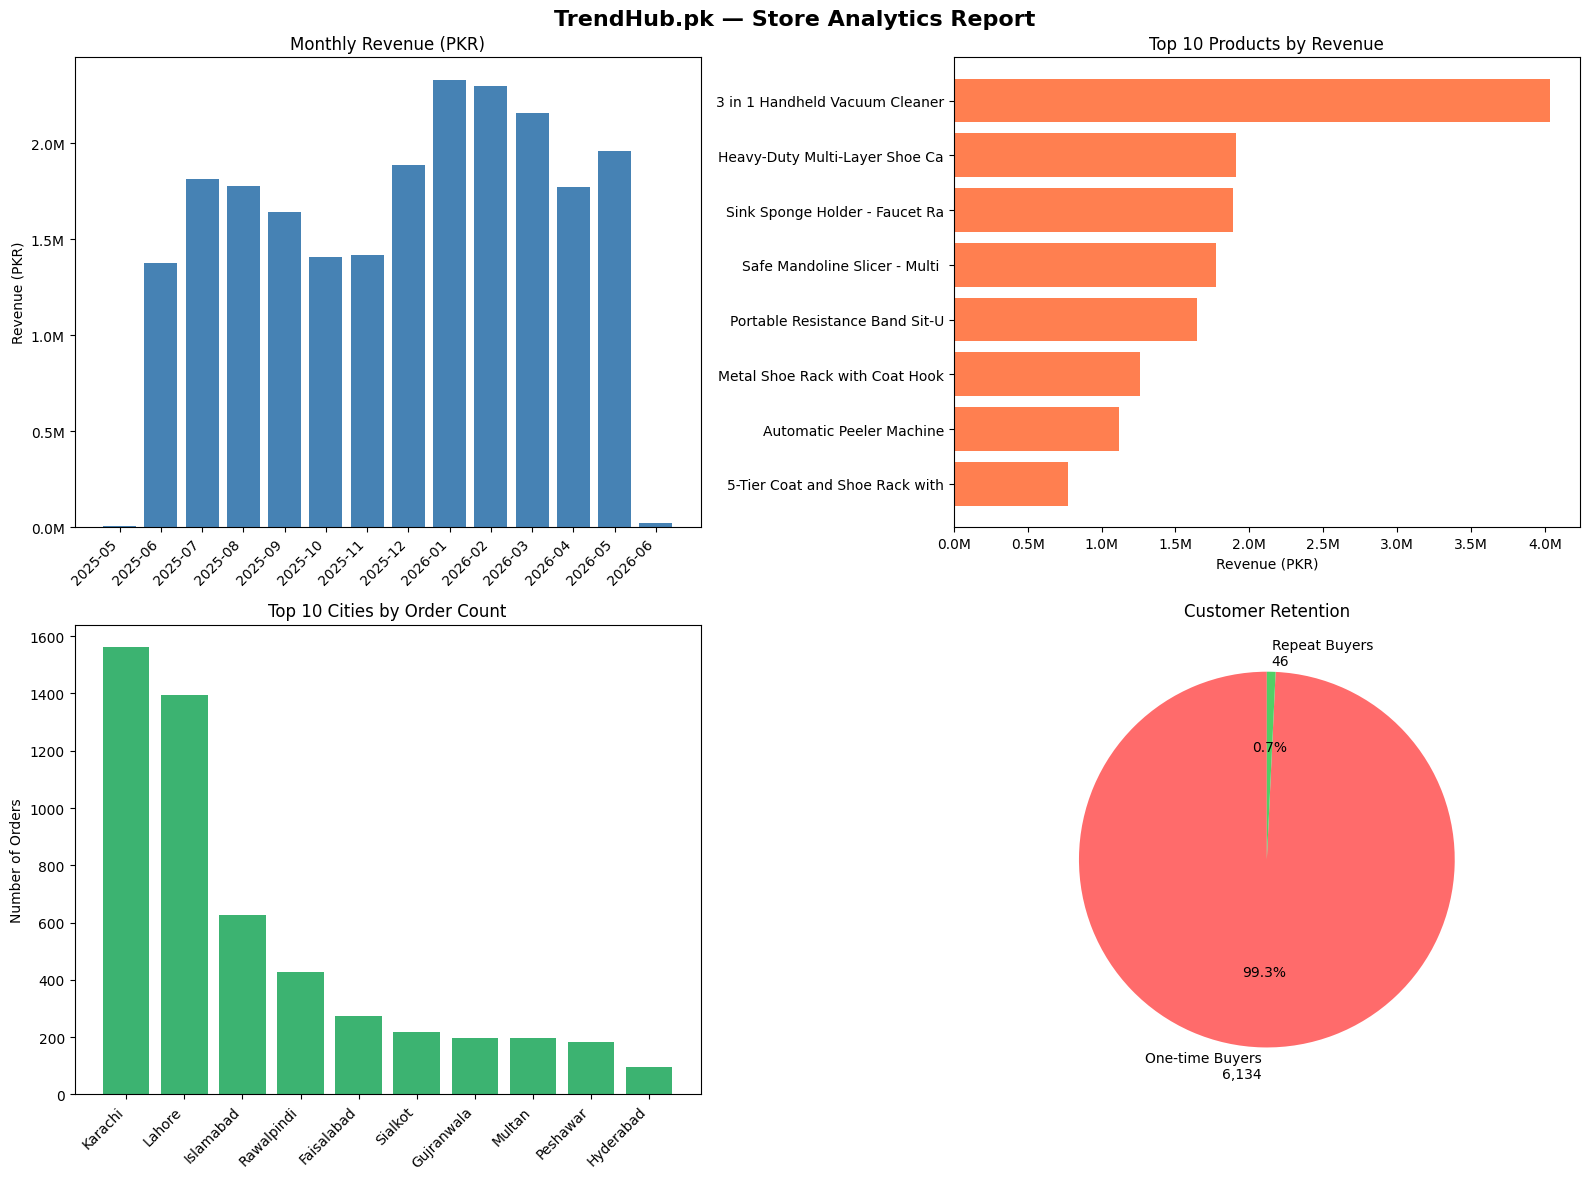

Chart saved as trendhub_report.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TrendHub.pk — Store Analytics Report', fontsize=16, fontweight='bold')

# 1. Monthly Revenue Trend
axes[0,0].bar(monthly_revenue['Month'], monthly_revenue['Revenue'], color='steelblue')
axes[0,0].set_title('Monthly Revenue (PKR)')
axes[0,0].set_xticklabels(monthly_revenue['Month'], rotation=45, ha='right')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0,0].set_ylabel('Revenue (PKR)')

# 2. Top 10 Products
top10 = product_revenue.head(10)
axes[0,1].barh(top10['Lineitem name'].str[:30], top10['Total_Revenue'], color='coral')
axes[0,1].set_title('Top 10 Products by Revenue')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0,1].set_xlabel('Revenue (PKR)')
axes[0,1].invert_yaxis()

# 3. Top 10 Cities by Orders
top_cities = city_revenue.head(10)
axes[1,0].bar(top_cities['City'], top_cities['Order Count'], color='mediumseagreen')
axes[1,0].set_title('Top 10 Cities by Order Count')
axes[1,0].set_xticklabels(top_cities['City'], rotation=45, ha='right')
axes[1,0].set_ylabel('Number of Orders')

# 4. Customer Retention
retention_data = [len(one_time_customers), len(repeat_customers)]
retention_labels = [f'One-time Buyers\n{len(one_time_customers):,}', f'Repeat Buyers\n{len(repeat_customers):,}']
axes[1,1].pie(retention_data, labels=retention_labels, colors=['#ff6b6b','#51cf66'], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Customer Retention')

plt.tight_layout()
plt.savefig('trendhub_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as trendhub_report.png")

/tmp/ipykernel_6294/2443968471.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(monthly_revenue['Month'], rotation=45, ha='right')
/tmp/ipykernel_6294/2443968471.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(top_cities['City'], rotation=45, ha='right')


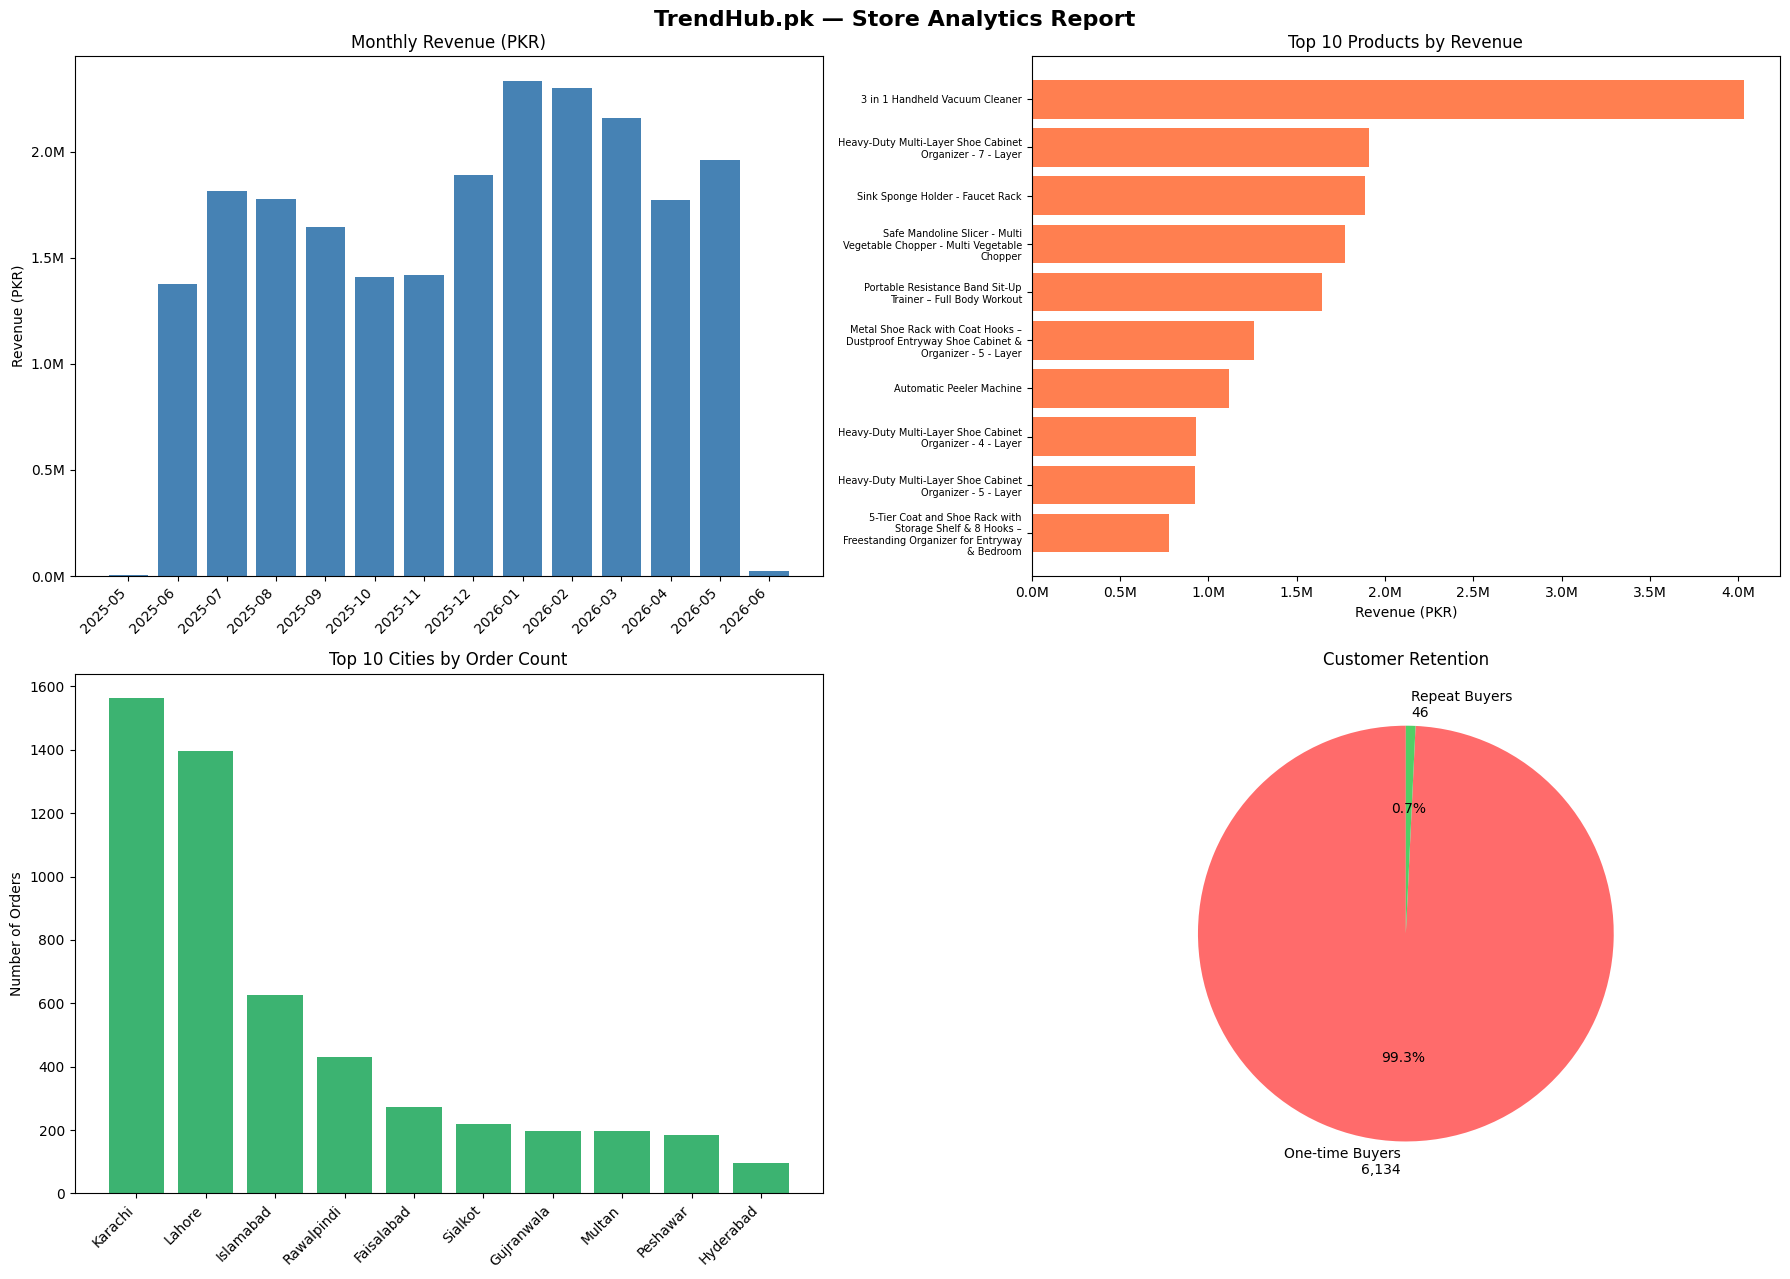

Saved as trendhub_report_v2.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('TrendHub.pk — Store Analytics Report', fontsize=16, fontweight='bold')

# 1. Monthly Revenue Trend
axes[0,0].bar(monthly_revenue['Month'], monthly_revenue['Revenue'], color='steelblue')
axes[0,0].set_title('Monthly Revenue (PKR)')
axes[0,0].set_xticklabels(monthly_revenue['Month'], rotation=45, ha='right')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0,0].set_ylabel('Revenue (PKR)')

# 2. Top 10 Products - wrap long names
import textwrap
top10 = product_revenue.head(10).copy()
top10['Short Name'] = top10['Lineitem name'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=35)))
axes[0,1].barh(top10['Short Name'], top10['Total_Revenue'], color='coral')
axes[0,1].set_title('Top 10 Products by Revenue')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0,1].set_xlabel('Revenue (PKR)')
axes[0,1].invert_yaxis()
axes[0,1].tick_params(axis='y', labelsize=7)

# 3. Top 10 Cities
top_cities = city_revenue.head(10)
axes[1,0].bar(top_cities['City'], top_cities['Order Count'], color='mediumseagreen')
axes[1,0].set_title('Top 10 Cities by Order Count')
axes[1,0].set_xticklabels(top_cities['City'], rotation=45, ha='right')
axes[1,0].set_ylabel('Number of Orders')

# 4. Customer Retention
retention_data = [len(one_time_customers), len(repeat_customers)]
retention_labels = [f'One-time Buyers\n{len(one_time_customers):,}', f'Repeat Buyers\n{len(repeat_customers):,}']
axes[1,1].pie(retention_data, labels=retention_labels, colors=['#ff6b6b','#51cf66'], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Customer Retention')

plt.tight_layout()
plt.savefig('trendhub_report_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as trendhub_report_v2.png")

In [ ]:
print("=" * 55)
print("TRENDHUB.PK — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
1. TOTAL REVENUE (June 2025 – May 2026)
   PKR 21,888,859 across 8,513 paid orders
   Average order value: PKR 2,571

2. GROWTH TRAJECTORY
   June 2025: PKR 1.37M → January 2026: PKR 2.33M
   70% revenue growth in 7 months
   ⚠ Revenue has declined 20% since January peak

3. RETENTION CRISIS
   6,180 customers with email tracked
   Only 46 ever bought a second time
   Repeat purchase rate: 0.7% (industry avg: 20-30%)
   6,134 one-time buyers never returned
   Potential recovery value (10% win-back at avg AOV):
   PKR {int(6134 * 0.10 * 2571):,}

4. PRODUCT CONCENTRATION RISK
   3 in 1 Handheld Vacuum Cleaner: PKR 4.03M
   Single product = 18.4% of total revenue
   Top 3 products = 40%+ of total revenue

5. GEOGRAPHIC OPPORTUNITY
   Karachi + Lahore + Islamabad = 41% of revenue
   Strong presence in 15+ cities
   Mid-tier cities (Sialkot, Gujranwala, Multan)
   showing meaningful traction — untapped ad potential
""")
print("=" * 55)

TRENDHUB.PK — KEY FINDINGS SUMMARY

1. TOTAL REVENUE (June 2025 – May 2026)
   PKR 21,888,859 across 8,513 paid orders
   Average order value: PKR 2,571

2. GROWTH TRAJECTORY
   June 2025: PKR 1.37M → January 2026: PKR 2.33M
   70% revenue growth in 7 months
   ⚠ Revenue has declined 20% since January peak

3. RETENTION CRISIS
   6,180 customers with email tracked
   Only 46 ever bought a second time
   Repeat purchase rate: 0.7% (industry avg: 20-30%)
   6,134 one-time buyers never returned
   Potential recovery value (10% win-back at avg AOV):
   PKR 1,577,051

4. PRODUCT CONCENTRATION RISK
   3 in 1 Handheld Vacuum Cleaner: PKR 4.03M
   Single product = 18.4% of total revenue
   Top 3 products = 40%+ of total revenue

5. GEOGRAPHIC OPPORTUNITY
   Karachi + Lahore + Islamabad = 41% of revenue
   Strong presence in 15+ cities
   Mid-tier cities (Sialkot, Gujranwala, Multan)
   showing meaningful traction — untapped ad potential



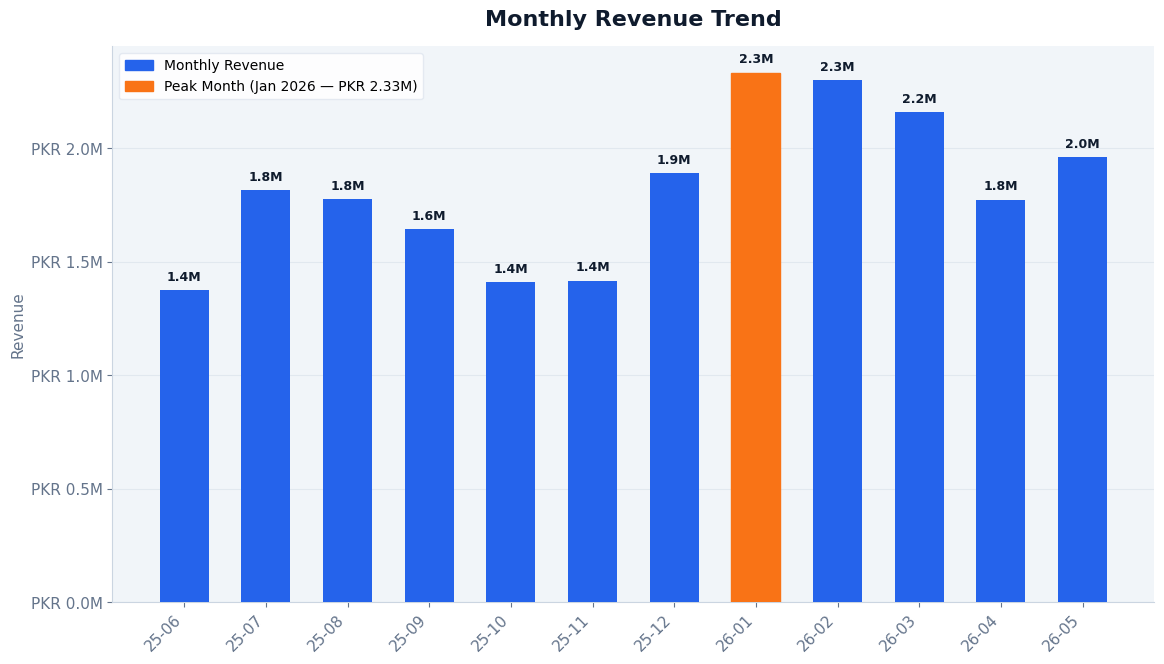

Chart 1 saved


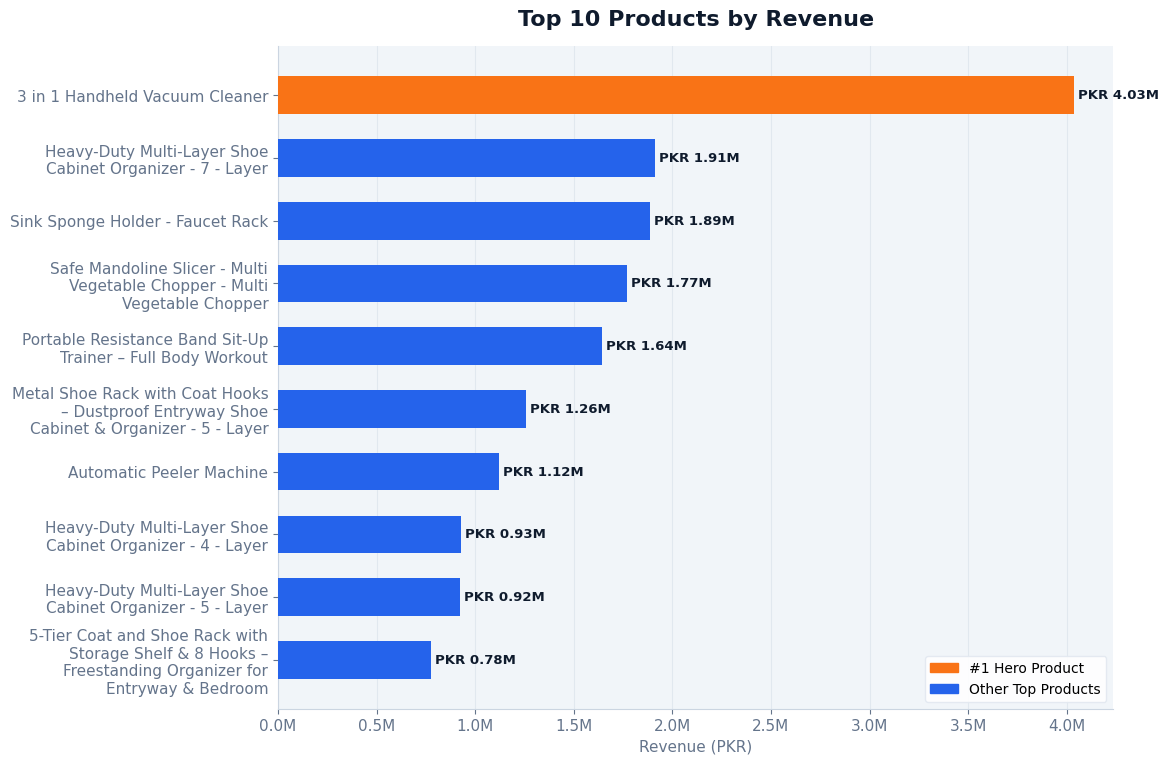

Chart 2 saved


/tmp/ipykernel_6294/1003161795.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_cities['City'], rotation=45, ha='right', fontsize=11)


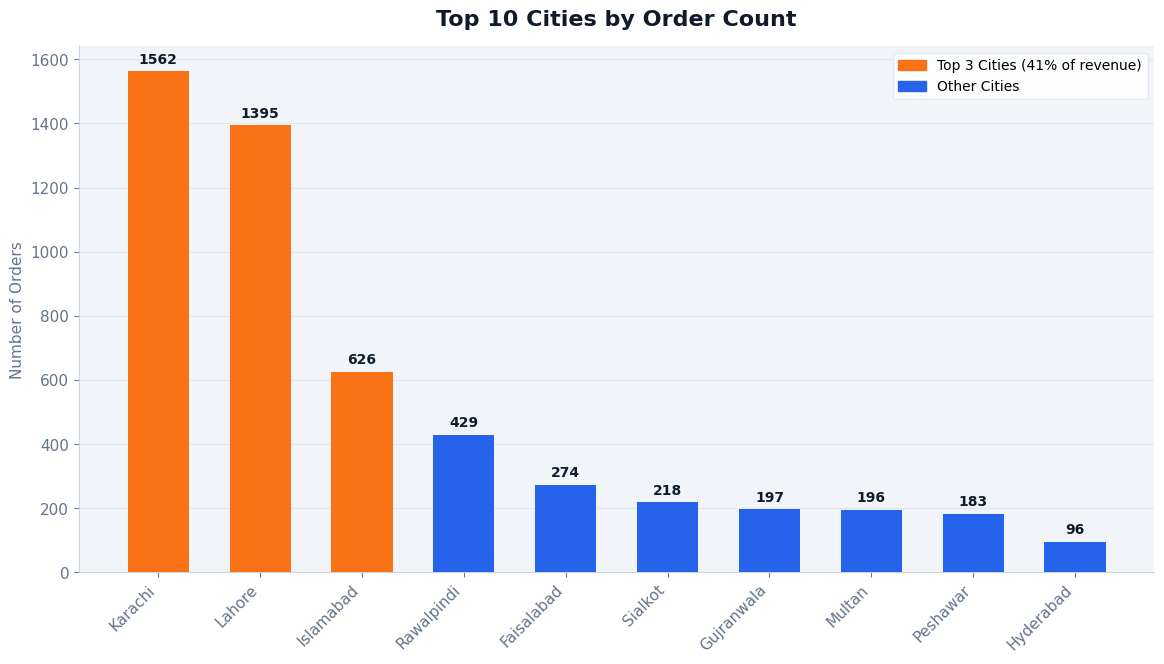

Chart 3 saved


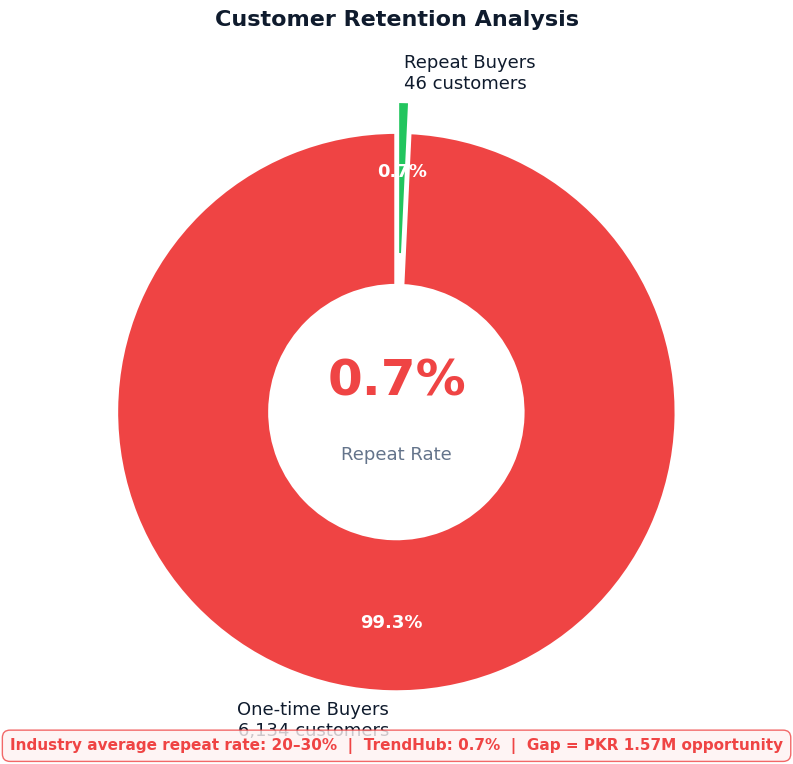

Chart 4 saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import textwrap

# ── Colour palette ──────────────────────────────────────────────
DARK_BG   = "#0F1B2D"
ACCENT    = "#2563EB"
ORANGE    = "#F97316"
GREEN     = "#22C55E"
PURPLE    = "#7C3AED"
LIGHT_BG  = "#F1F5F9"
WHITE     = "#FFFFFF"
GREY_TEXT = "#64748B"

def style_axis(ax, dark=False):
    bg = DARK_BG if dark else LIGHT_BG
    ax.set_facecolor(bg)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    ax.spines['bottom'].set_color('#CBD5E1')
    ax.tick_params(colors=GREY_TEXT if not dark else '#94A3B8', labelsize=11)
    ax.yaxis.label.set_color(GREY_TEXT)
    ax.xaxis.label.set_color(GREY_TEXT)

# ── CHART 1: Monthly Revenue ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(LIGHT_BG)

months_plot = monthly_revenue[~monthly_revenue['Month'].isin(['2025-05','2026-06'])].copy()
x = range(len(months_plot))
bars = ax.bar(x, months_plot['Revenue'], color=ACCENT, width=0.6, zorder=3)

# Highlight peak bar
max_idx = months_plot['Revenue'].idxmax()
peak_pos = list(months_plot.index).index(max_idx)
bars[peak_pos].set_color(ORANGE)

# Value labels on bars
for i, (bar, val) in enumerate(zip(bars, months_plot['Revenue'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
            f'{val/1e6:.1f}M', ha='center', va='bottom',
            fontsize=9, color=DARK_BG, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels([m[2:] for m in months_plot['Month']], rotation=45, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'PKR {v/1e6:.1f}M'))
ax.set_ylabel('Revenue', fontsize=11)
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=15, color=DARK_BG)
ax.grid(axis='y', alpha=0.4, color='#CBD5E1', zorder=0)
style_axis(ax)

peak_patch = mpatches.Patch(color=ORANGE, label='Peak Month (Jan 2026 — PKR 2.33M)')
blue_patch = mpatches.Patch(color=ACCENT, label='Monthly Revenue')
ax.legend(handles=[blue_patch, peak_patch], fontsize=10, loc='upper left',
          framealpha=0.9, edgecolor='#E2E8F0')

plt.tight_layout(pad=2)
plt.savefig('chart1_monthly_revenue.png', dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 1 saved")

# ── CHART 2: Top 10 Products ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(LIGHT_BG)

top10 = product_revenue.head(10).copy()
top10['Short'] = top10['Lineitem name'].apply(lambda x: '\n'.join(textwrap.wrap(x, 32)))
colors_list = [ORANGE] + [ACCENT] * 9
bars = ax.barh(top10['Short'], top10['Total_Revenue'],
               color=colors_list, height=0.6, zorder=3)

for bar, val in zip(bars, top10['Total_Revenue']):
    ax.text(bar.get_width() + 20000, bar.get_y() + bar.get_height()/2,
            f'PKR {val/1e6:.2f}M', va='center', fontsize=9.5,
            color=DARK_BG, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.set_xlabel('Revenue (PKR)', fontsize=11)
ax.set_title('Top 10 Products by Revenue', fontsize=16, fontweight='bold', pad=15, color=DARK_BG)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4, color='#CBD5E1', zorder=0)
ax.tick_params(axis='y', labelsize=9.5)
style_axis(ax)

orange_patch = mpatches.Patch(color=ORANGE, label='#1 Hero Product')
blue_patch   = mpatches.Patch(color=ACCENT, label='Other Top Products')
ax.legend(handles=[orange_patch, blue_patch], fontsize=10,
          framealpha=0.9, edgecolor='#E2E8F0')

plt.tight_layout(pad=2)
plt.savefig('chart2_products.png', dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 2 saved")

# ── CHART 3: Top Cities ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(LIGHT_BG)

top_cities = city_revenue.head(10).copy()
city_colors = [ORANGE, ORANGE, ORANGE] + [ACCENT] * 7  # top 3 highlighted
bars = ax.bar(top_cities['City'], top_cities['Order Count'],
              color=city_colors, width=0.6, zorder=3)

for bar, val in zip(bars, top_cities['Order Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', va='bottom',
            fontsize=10, color=DARK_BG, fontweight='bold')

ax.set_xticklabels(top_cities['City'], rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.set_title('Top 10 Cities by Order Count', fontsize=16, fontweight='bold', pad=15, color=DARK_BG)
ax.grid(axis='y', alpha=0.4, color='#CBD5E1', zorder=0)
style_axis(ax)

top3_patch = mpatches.Patch(color=ORANGE, label='Top 3 Cities (41% of revenue)')
other_patch = mpatches.Patch(color=ACCENT, label='Other Cities')
ax.legend(handles=[top3_patch, other_patch], fontsize=10,
          framealpha=0.9, edgecolor='#E2E8F0')

plt.tight_layout(pad=2)
plt.savefig('chart3_cities.png', dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 3 saved")

# ── CHART 4: Retention Donut ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

sizes  = [6134, 46]
labels = ['One-time Buyers\n6,134 customers', 'Repeat Buyers\n46 customers']
clrs   = ['#EF4444', '#22C55E']
explode = (0.03, 0.08)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=clrs, autopct='%1.1f%%',
    startangle=90, explode=explode,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=13, color=DARK_BG),
    pctdistance=0.75)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

# Centre label
ax.text(0, 0.08, '0.7%', ha='center', va='center',
        fontsize=36, fontweight='bold', color='#EF4444')
ax.text(0, -0.18, 'Repeat Rate', ha='center', va='center',
        fontsize=13, color=GREY_TEXT)

ax.set_title('Customer Retention Analysis', fontsize=16,
             fontweight='bold', pad=20, color=DARK_BG)

# Callout box
fig.text(0.5, 0.04,
         'Industry average repeat rate: 20–30%  |  TrendHub: 0.7%  |  Gap = PKR 1.57M opportunity',
         ha='center', fontsize=11, color='#EF4444', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEF2F2', edgecolor='#EF4444', alpha=0.8))

plt.tight_layout(pad=2)
plt.savefig('chart4_retention.png', dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 4 saved")

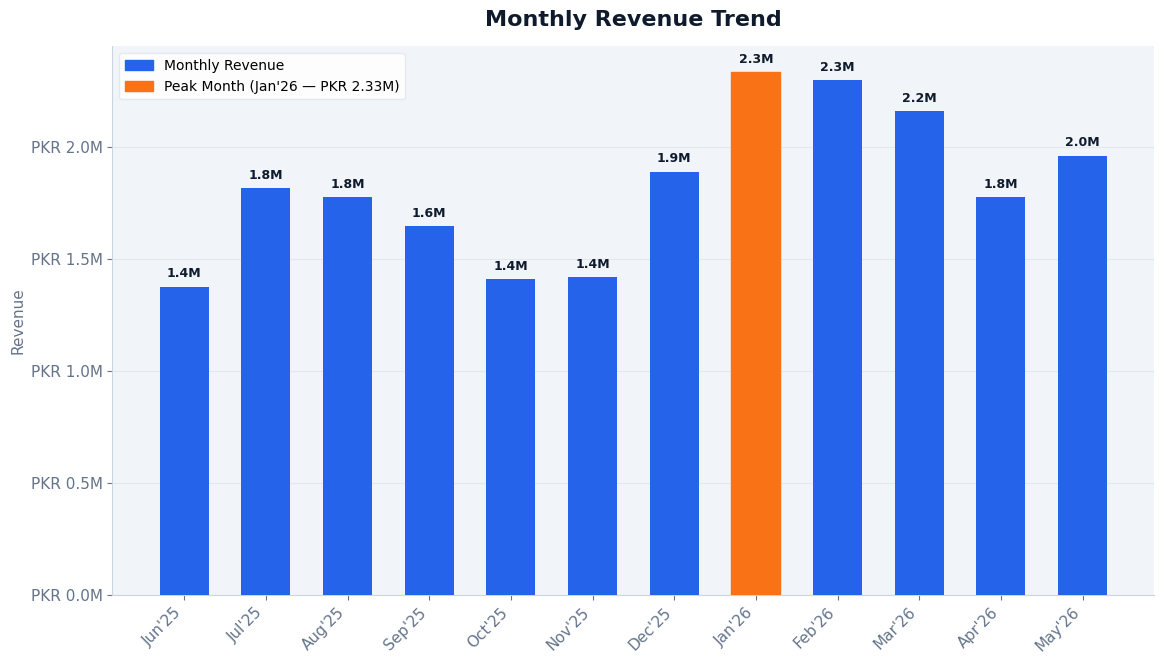

Chart 1 saved


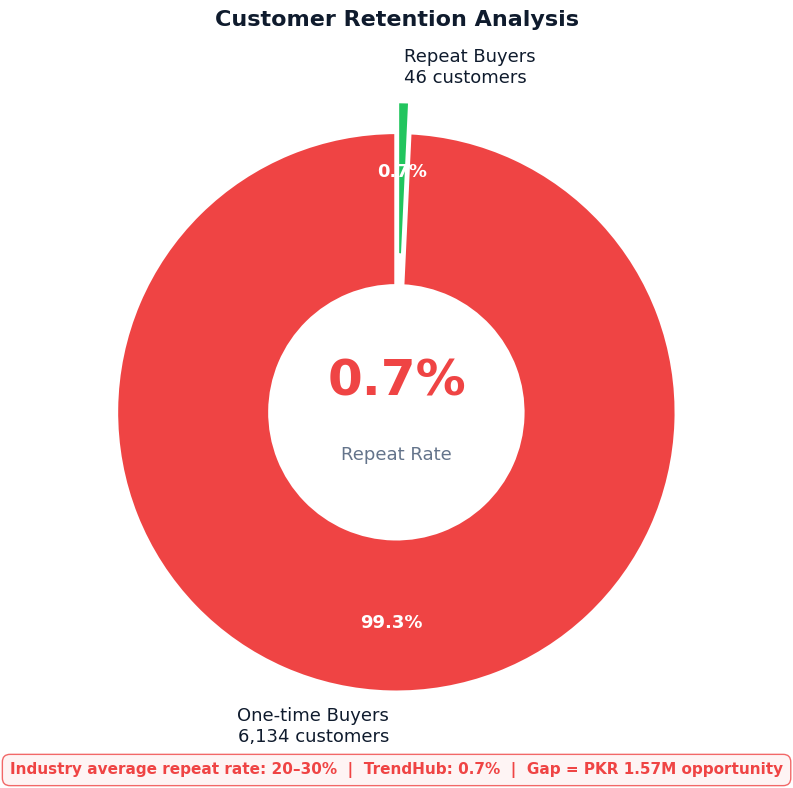

Chart 4 saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import textwrap

DARK_BG  = "#0F1B2D"
ACCENT   = "#2563EB"
ORANGE   = "#F97316"
GREEN    = "#22C55E"
WHITE    = "#FFFFFF"
GREY_TEXT= "#64748B"
LIGHT_BG = "#F1F5F9"

def style_axis(ax):
    ax.set_facecolor(LIGHT_BG)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    ax.spines['bottom'].set_color('#CBD5E1')
    ax.tick_params(colors=GREY_TEXT, labelsize=11)
    ax.yaxis.label.set_color(GREY_TEXT)
    ax.xaxis.label.set_color(GREY_TEXT)

# ── CHART 1 FIX: Better x-axis labels ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(LIGHT_BG)

months_plot = monthly_revenue[~monthly_revenue['Month'].isin(['2025-05','2026-06'])].copy()

# Convert "2025-06" → "Jun'25"
month_map = {
    '2025-06': "Jun'25", '2025-07': "Jul'25", '2025-08': "Aug'25",
    '2025-09': "Sep'25", '2025-10': "Oct'25", '2025-11': "Nov'25",
    '2025-12': "Dec'25", '2026-01': "Jan'26", '2026-02': "Feb'26",
    '2026-03': "Mar'26", '2026-04': "Apr'26", '2026-05': "May'26",
}
months_plot['Label'] = months_plot['Month'].map(month_map)

x = range(len(months_plot))
bars = ax.bar(x, months_plot['Revenue'], color=ACCENT, width=0.6, zorder=3)

max_idx = months_plot['Revenue'].idxmax()
peak_pos = list(months_plot.index).index(max_idx)
bars[peak_pos].set_color(ORANGE)

for bar, val in zip(bars, months_plot['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
            f'{val/1e6:.1f}M', ha='center', va='bottom',
            fontsize=9, color=DARK_BG, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(months_plot['Label'], rotation=45, ha='right', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'PKR {v/1e6:.1f}M'))
ax.set_ylabel('Revenue', fontsize=11)
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=15, color=DARK_BG)
ax.grid(axis='y', alpha=0.4, color='#CBD5E1', zorder=0)
style_axis(ax)

peak_patch = mpatches.Patch(color=ORANGE, label="Peak Month (Jan'26 — PKR 2.33M)")
blue_patch = mpatches.Patch(color=ACCENT,  label='Monthly Revenue')
ax.legend(handles=[blue_patch, peak_patch], fontsize=10, loc='upper left',
          framealpha=0.9, edgecolor='#E2E8F0')

plt.tight_layout(pad=2)
plt.savefig('chart1_monthly_revenue.png', dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 1 saved")

# ── CHART 4 FIX: Move callout box down ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

sizes   = [6134, 46]
labels  = ['One-time Buyers\n6,134 customers', 'Repeat Buyers\n46 customers']
clrs    = ['#EF4444', '#22C55E']
explode = (0.03, 0.08)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=clrs, autopct='%1.1f%%',
    startangle=90, explode=explode,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=13, color=DARK_BG),
    pctdistance=0.75,
    labeldistance=1.12)   # push labels further out so nothing overlaps

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

ax.text(0, 0.08, '0.7%', ha='center', va='center',
        fontsize=36, fontweight='bold', color='#EF4444')
ax.text(0, -0.18, 'Repeat Rate', ha='center', va='center',
        fontsize=13, color=GREY_TEXT)

ax.set_title('Customer Retention Analysis', fontsize=16,
             fontweight='bold', pad=20, color=DARK_BG)

# Moved callout lower — y=0.01 instead of 0.04
fig.text(0.5, 0.01,
         'Industry average repeat rate: 20–30%  |  TrendHub: 0.7%  |  Gap = PKR 1.57M opportunity',
         ha='center', fontsize=11, color='#EF4444', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEF2F2',
                   edgecolor='#EF4444', alpha=0.8))

plt.tight_layout(pad=2)
plt.savefig('chart4_retention.png', dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 4 saved")

In [3]:
import pandas as pd

# Reload and rebuild everything
df1 = pd.read_csv('orders_export_1.csv', low_memory=False)
df2 = pd.read_csv('orders_export_2.csv', low_memory=False)
df = pd.concat([df1, df2], ignore_index=True)
df['Created at'] = pd.to_datetime(df['Created at'], utc=True)
df_clean = df[df['Financial Status'] == 'paid'].copy()
df_orders = df_clean.drop_duplicates(subset='Name').copy()

print("Data reloaded:", df_orders.shape[0], "paid orders")

Data reloaded: 8513 paid orders


In [4]:
from datetime import timedelta

# ── Overall Return Rate ──────────────────────────────────────────
total_orders = df_orders.shape[0]
refunded_orders = df[df['Financial Status'] == 'refunded'].drop_duplicates(subset='Name').shape[0]
voided_orders = df[df['Financial Status'] == 'voided'].drop_duplicates(subset='Name').shape[0]

overall_return_rate = (refunded_orders / total_orders) * 100

print("=" * 45)
print("OVERALL RETURN / REFUND STATS")
print("=" * 45)
print(f"Total paid orders:       {total_orders:,}")
print(f"Refunded orders:         {refunded_orders:,}")
print(f"Overall return rate:     {overall_return_rate:.2f}%")

# ── Last 3 Months Return Rate ────────────────────────────────────
cutoff = df_orders['Created at'].max() - pd.DateOffset(months=3)

recent_paid = df_orders[df_orders['Created at'] >= cutoff].shape[0]

df_refunded = df[df['Financial Status'] == 'refunded'].copy()
df_refunded['Created at'] = pd.to_datetime(df_refunded['Created at'], utc=True)
df_refunded_dedup = df_refunded.drop_duplicates(subset='Name')
recent_refunded = df_refunded_dedup[df_refunded_dedup['Created at'] >= cutoff].shape[0]

recent_return_rate = (recent_refunded / recent_paid) * 100 if recent_paid > 0 else 0

print()
print("=" * 45)
print("LAST 3 MONTHS RETURN / REFUND STATS")
print("=" * 45)
print(f"Paid orders (last 3 months):     {recent_paid:,}")
print(f"Refunded orders (last 3 months): {recent_refunded:,}")
print(f"Return rate (last 3 months):     {recent_return_rate:.2f}%")

OVERALL RETURN / REFUND STATS
Total paid orders:       8,513
Refunded orders:         21
Overall return rate:     0.25%

LAST 3 MONTHS RETURN / REFUND STATS
Paid orders (last 3 months):     2,391
Refunded orders (last 3 months): 0
Return rate (last 3 months):     0.00%


In [5]:
print("All Financial Status values:")
print(df['Financial Status'].value_counts())

print("\nAll Fulfillment Status values:")
print(df['Fulfillment Status'].value_counts())

print("\nSample of refunded/voided orders:")
print(df[df['Financial Status'].isin(['refunded', 'voided'])][
    ['Name', 'Financial Status', 'Fulfillment Status', 'Total', 'Refunded Amount']
].head(20).to_string())

All Financial Status values:
Financial Status
paid        8513
voided      7864
pending     1148
refunded      21
Name: count, dtype: int64

All Fulfillment Status values:
Fulfillment Status
fulfilled      13286
unfulfilled     4258
restocked          2
Name: count, dtype: int64

Sample of refunded/voided orders:
         Name Financial Status Fulfillment Status   Total  Refunded Amount
14   #TH28948           voided        unfulfilled   949.0              0.0
17   #TH28945           voided        unfulfilled  3249.0              0.0
28   #TH28934           voided        unfulfilled  2299.0              0.0
39   #TH28924           voided        unfulfilled  1999.0              0.0
46   #TH28918           voided        unfulfilled  4599.0              0.0
52   #TH28912           voided        unfulfilled  1749.0              0.0
69   #TH28897           voided        unfulfilled   949.0              0.0
73   #TH28893           voided        unfulfilled  1249.0              0.0
76   #TH28

In [6]:
print("Orders with a Refunded Amount > 0:")
refunded_amounts = df[df['Refunded Amount'] > 0]
print(f"Count: {refunded_amounts.shape[0]}")
print(f"\nTotal refunded value: PKR {refunded_amounts['Refunded Amount'].sum():,.0f}")
print(f"\nBreakdown by Financial Status:")
print(refunded_amounts['Financial Status'].value_counts())

Orders with a Refunded Amount > 0:
Count: 21

Total refunded value: PKR 54,878

Breakdown by Financial Status:
Financial Status
refunded    21
Name: count, dtype: int64


In [7]:
# What % of all orders are voided
all_orders = df.drop_duplicates(subset='Name')
total = all_orders.shape[0]
voided = all_orders[all_orders['Financial Status'] == 'voided'].shape[0]
paid = all_orders[all_orders['Financial Status'] == 'paid'].shape[0]

print(f"Total unique orders:   {total:,}")
print(f"Paid orders:           {paid:,}  ({paid/total*100:.1f}%)")
print(f"Voided orders:         {voided:,}  ({voided/total*100:.1f}%)")
print(f"\nFor every 100 orders placed, {voided/total*100:.0f} were voided/undelivered")

Total unique orders:   17,546
Paid orders:           8,513  (48.5%)
Voided orders:         7,864  (44.8%)

For every 100 orders placed, 45 were voided/undelivered


In [8]:
# Revenue lost to voided orders
avg_order_value = df_orders['Total'].mean()
voided_unique = df.drop_duplicates(subset='Name')
voided_unique = voided_unique[voided_unique['Financial Status'] == 'voided']
voided_revenue = voided_unique['Total'].sum()

# Assuming courier cost per attempt (typical Pakistani courier PKR 200-300)
courier_cost_per_order = 250
courier_loss = voided * courier_cost_per_order

print(f"Average order value:          PKR {avg_order_value:,.0f}")
print(f"Revenue lost to voided orders: PKR {voided_revenue:,.0f}")
print(f"Estimated courier cost waste:  PKR {courier_loss:,.0f}")
print(f"Total estimated impact:        PKR {voided_revenue + courier_loss:,.0f}")

Average order value:          PKR 2,571
Revenue lost to voided orders: PKR 180,021,258
Estimated courier cost waste:  PKR 1,966,000
Total estimated impact:        PKR 181,987,258


In [9]:
voided_unique = df.drop_duplicates(subset='Name')
voided_unique = voided_unique[voided_unique['Financial Status'] == 'voided']

print(f"Voided/undelivered orders:     {voided:,}")
print(f"Estimated courier cost per attempt: PKR 250")
print(f"Estimated courier fees wasted: PKR {voided * 250:,.0f}")
print(f"\nOut of every 100 orders, 45 don't convert.")
print(f"That means for every PKR 100 spent on fulfillment, PKR 45 is wasted on failed deliveries.")

Voided/undelivered orders:     7,864
Estimated courier cost per attempt: PKR 250
Estimated courier fees wasted: PKR 1,966,000

Out of every 100 orders, 45 don't convert.
That means for every PKR 100 spent on fulfillment, PKR 45 is wasted on failed deliveries.


In [10]:
voided = df.drop_duplicates(subset='Name')
voided = voided[voided['Financial Status'] == 'voided']

cancelled = voided[voided['Fulfillment Status'] == 'unfulfilled']
returned = voided[voided['Fulfillment Status'] == 'fulfilled']

total_orders = df.drop_duplicates(subset='Name').shape[0]

print(f"Total unique orders:          {total_orders:,}")
print(f"\nVoided breakdown:")
print(f"  Cancelled (never dispatched): {len(cancelled):,}  ({len(cancelled)/total_orders*100:.1f}%)")
print(f"  Returned (fulfilled→voided):  {len(returned):,}  ({len(returned)/total_orders*100:.1f}%)")
print(f"\nReturn rate (of all orders):  {len(returned)/total_orders*100:.1f}%")
print(f"Return rate (of paid orders): {len(returned)/df_orders.shape[0]*100:.1f}%")

Total unique orders:          17,546

Voided breakdown:
  Cancelled (never dispatched): 4,239  (24.2%)
  Returned (fulfilled→voided):  3,625  (20.7%)

Return rate (of all orders):  20.7%
Return rate (of paid orders): 42.6%


In [11]:
dispatched = df_orders.shape[0] + len(returned)

print(f"Total dispatched orders:      {dispatched:,}")
print(f"Successfully delivered:        {df_orders.shape[0]:,}  ({df_orders.shape[0]/dispatched*100:.1f}%)")
print(f"Returned after fulfillment:    {len(returned):,}  ({len(returned)/dispatched*100:.1f}%)")
print(f"\nEstimated courier cost of returns: PKR {len(returned)*250:,.0f}")

Total dispatched orders:      12,138
Successfully delivered:        8,513  (70.1%)
Returned after fulfillment:    3,625  (29.9%)

Estimated courier cost of returns: PKR 906,250


In [12]:
# Last 3 months cutoff
cutoff = df['Created at'].max() - pd.DateOffset(months=3)

# Filter to last 3 months
recent = df.drop_duplicates(subset='Name')
recent = recent[recent['Created at'] >= cutoff]

recent_total = len(recent)
recent_paid = len(recent[recent['Financial Status'] == 'paid'])
recent_voided = len(recent[recent['Financial Status'] == 'voided'])
recent_pending = len(recent[recent['Financial Status'] == 'pending'])

print(f"Last 3 months order breakdown:")
print(f"Total orders:    {recent_total:,}")
print(f"Paid/delivered:  {recent_paid:,}  ({recent_paid/recent_total*100:.1f}%)")
print(f"Voided:          {recent_voided:,}  ({recent_voided/recent_total*100:.1f}%)")
print(f"Pending:         {recent_pending:,}  ({recent_pending/recent_total*100:.1f}%)")

Last 3 months order breakdown:
Total orders:    5,433
Paid/delivered:  2,298  (42.3%)
Voided:          2,165  (39.8%)
Pending:         970  (17.9%)


In [13]:
# Exclude pending to get resolved orders only
resolved = recent[recent['Financial Status'] != 'pending']
resolved_total = len(resolved)
resolved_paid = len(resolved[resolved['Financial Status'] == 'paid'])
resolved_voided = len(resolved[resolved['Financial Status'] == 'voided'])

print(f"Last 3 months (resolved orders only):")
print(f"Total resolved:  {resolved_total:,}")
print(f"Paid/delivered:  {resolved_paid:,}  ({resolved_paid/resolved_total*100:.1f}%)")
print(f"Voided:          {resolved_voided:,}  ({resolved_voided/resolved_total*100:.1f}%)")

Last 3 months (resolved orders only):
Total resolved:  4,463
Paid/delivered:  2,298  (51.5%)
Voided:          2,165  (48.5%)


In [14]:
resolved_all = df.drop_duplicates(subset='Name')
resolved_all = resolved_all[resolved_all['Financial Status'] != 'pending']

print(f"Full year (resolved orders only):")
print(f"Total resolved:  {len(resolved_all):,}")
print(f"Paid/delivered:  {len(resolved_all[resolved_all['Financial Status'] == 'paid']):,}  ({len(resolved_all[resolved_all['Financial Status'] == 'paid'])/len(resolved_all)*100:.1f}%)")
print(f"Voided:          {len(resolved_all[resolved_all['Financial Status'] == 'voided']):,}  ({len(resolved_all[resolved_all['Financial Status'] == 'voided'])/len(resolved_all)*100:.1f}%)")

Full year (resolved orders only):
Total resolved:  16,398
Paid/delivered:  8,513  (51.9%)
Voided:          7,864  (48.0%)


In [1]:
import pandas as pd
import numpy as np

# Reload data
df1 = pd.read_csv('orders_export_1.csv', low_memory=False)
df2 = pd.read_csv('orders_export_2.csv', low_memory=False)
df = pd.concat([df1, df2], ignore_index=True)
df['Created at'] = pd.to_datetime(df['Created at'], utc=True)
df_clean = df[df['Financial Status'] == 'paid'].copy()
df_orders = df_clean.drop_duplicates(subset='Name').copy()

print("Data reloaded:", df_orders.shape[0], "paid orders")

# Anonymise - take a sample of 500 orders
sample = df_orders.sample(500, random_state=42).copy()

# Replace sensitive columns
sample['Email'] = ['customer_' + str(i) + '@example.com' for i in range(len(sample))]
sample['Billing Name'] = ['Customer ' + str(i) for i in range(len(sample))]
sample['Billing Phone'] = ['XXXXXXXXXX'] * len(sample)
sample['Billing Address1'] = ['XXXXXXXXXX'] * len(sample)
sample['Billing Street'] = ['XXXXXXXXXX'] * len(sample)
sample['Shipping Name'] = ['Customer ' + str(i) for i in range(len(sample))]
sample['Shipping Phone'] = ['XXXXXXXXXX'] * len(sample)
sample['Shipping Address1'] = ['XXXXXXXXXX'] * len(sample)
sample['Shipping Street'] = ['XXXXXXXXXX'] * len(sample)
sample['Phone'] = ['XXXXXXXXXX'] * len(sample)
sample['Name'] = ['#TH' + str(10000 + i) for i in range(len(sample))]

sample.to_csv('sample_data_anonymised.csv', index=False)
print("Anonymised sample saved:", len(sample), "orders")

Data reloaded: 8513 paid orders
Anonymised sample saved: 500 orders
